# Using Pipelines with Probatus

[![open in colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ing-bank/probatus/blob/master/docs/tutorials/pipelines.ipynb)

This notebook demonstrates how to use scikit-learn pipelines with Probatus for model validation.

## Introduction

[Probatus](https://github.com/ing-bank/probatus) is a Python package for validating classification and regression models. When combined with scikit-learn pipelines, it provides powerful tools for:

1. **Model interpretation** - Understanding what features drive your model's predictions
2. **Feature selection** - Identifying the most important features
3. **Dataset comparison** - Detecting distribution shifts between datasets

Pipelines ensure that preprocessing steps are consistently applied throughout model development and validation.

In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier

# Import probatus modules
from probatus.interpret import ShapModelInterpreter
from probatus.sample_similarity import SHAPImportanceResemblance

# Set random state for reproducibility
RANDOM_STATE = 42

## Data Preparation

We'll use the breast cancer dataset from scikit-learn, which is a binary classification problem.
The dataset contains features computed from digitized images of breast mass cells.

In [2]:
# Load and prepare the data
cancer = load_breast_cancer()
X = pd.DataFrame(cancer.data, columns=cancer.feature_names)
y = pd.Series(cancer.target)

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=RANDOM_STATE)

## Creating a Pipeline

Scikit-learn pipelines combine preprocessing steps with a model into a single object.
This ensures that:

- The same preprocessing is applied consistently
- Data leakage is prevented (preprocessing is fit only on training data)
- The entire workflow can be cross-validated

Here we create a pipeline with standardization and a Random Forest classifier:

In [3]:
# Create a pipeline with preprocessing and a Random Forest classifier
preprocessor = ColumnTransformer(transformers=[("num", StandardScaler(), X.columns)], remainder="passthrough")
rf_pipeline = Pipeline(
    [
        ("preprocessor", preprocessor),
        ("classifier", RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE)),
    ]
)

# Train the pipeline
rf_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('num', StandardScaler(),
                                                  Index(['mean radius', 'mean texture', 'mean perimeter', 'mean area',
       'mean smoothness', 'mean compactness', 'mean concavity',
       'mean concave points', 'mean symmetry', 'mean fractal dimension',
       'radius error', 'texture error', 'perimeter error', 'area error',
       'smoothnes...r', 'compactness error', 'concavity error',
       'concave points error', 'symmetry error', 'fractal dimension error',
       'worst radius', 'worst texture', 'worst perimeter', 'worst area',
       'worst smoothness', 'worst compactness', 'worst concavity',
       'worst concave points', 'worst symmetry', 'worst fractal dimension'],
      dtype='object'))])),
                ('classifier', RandomForestClassifier(random_state=42))])

## Model Interpretation with SHAP

A major advantage of Probatus is its ability to interpret models using SHAP values.
SHAP (SHapley Additive exPlanations) values explain the output of any machine learning model.

Probatus' `ShapModelInterpreter` class works seamlessly with pipelines, handling preprocessing
automatically before calculating SHAP values.

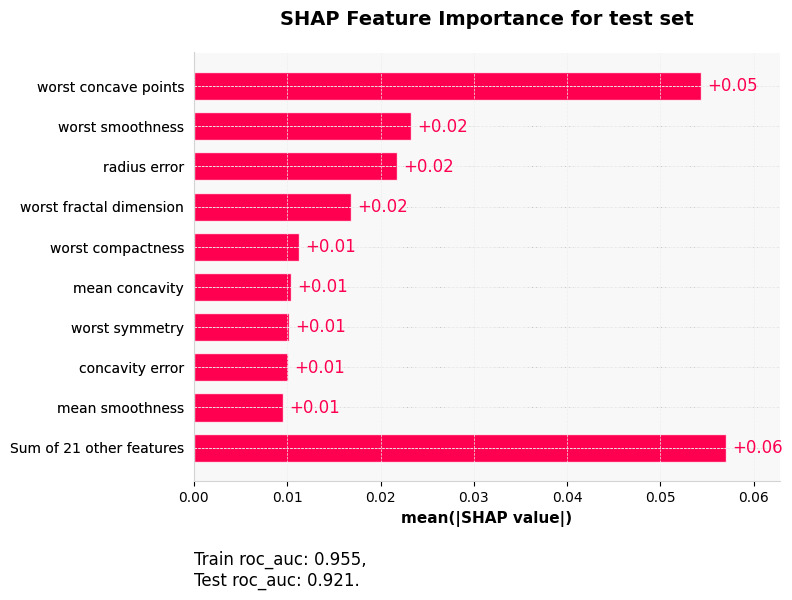

In [4]:
# Use ShapModelInterpreter with the Random Forest pipeline
shap_interpreter = ShapModelInterpreter(model=rf_pipeline, scoring="roc_auc", verbose=0, random_state=RANDOM_STATE)

# Fit the interpreter on the test data and compute SHAP values
shap_interpreter.fit_compute(X_train=X_train, X_test=X_test, y_train=y_train, y_test=y_test)

# Plot SHAP summary
shap_interpreter.plot("importance", show=False)

## Comparing Datasets with Resemblance Modeling

Probatus can detect differences between datasets using resemblance modeling.
This technique trains a model to distinguish between two datasets, and the features
the model uses most effectively indicate where the datasets differ.

This is particularly useful for:
- Detecting data drift over time
- Validating that test data represents the training distribution
- Identifying biases between datasets

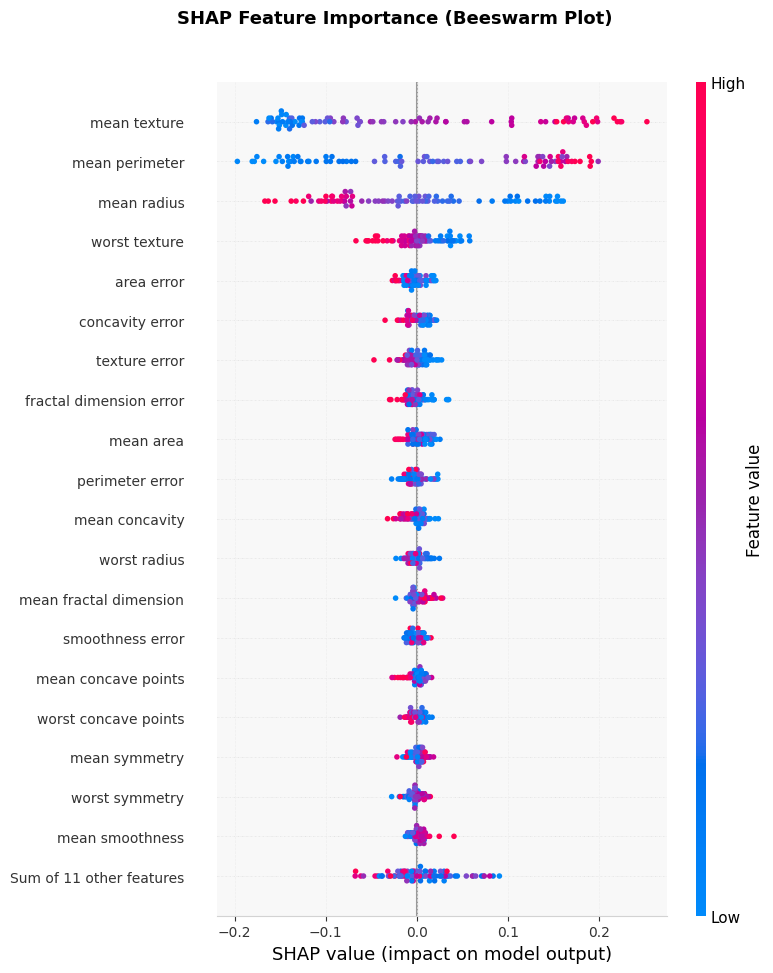

In [5]:
# Create a synthetic dataset with drift
np.random.seed(RANDOM_STATE)
X_test_shifted = X_test.copy()

# Add drift to the first 3 features
for feature in X_test.columns[:3]:
    shift_factor = np.random.uniform(0.7, 1.3)
    X_test_shifted[feature] = X_test_shifted[feature] * shift_factor

# Use SHAPImportanceResemblance with a pipeline to compare datasets
resemblance_model = SHAPImportanceResemblance(model=rf_pipeline, test_prc=0.3, random_state=RANDOM_STATE)

# Fit the resemblance model to compare X_test and X_test_shifted
resemblance_model.fit(X_test, X_test_shifted)

# Compute and plot feature importance
importance_df = resemblance_model.compute()
resemblance_model.plot("beeswarm", show=False)

## Conclusion

This notebook demonstrated how to:

1. Create scikit-learn pipelines for preprocessing and modeling
2. Use pipelines with Probatus for model interpretation via SHAP values
3. Apply resemblance modeling to detect dataset differences

The key benefits of using pipelines with Probatus include:

- **Consistency** - Preprocessing is applied uniformly across training and evaluation
- **Convenience** - Probatus handles extracting the model from the pipeline
- **Interpretability** - SHAP values are calculated on the post-processed data

For more advanced usage, explore Probatus' other modules like feature elimination,
model selection, and sample similarity features.